# Using CelebA with FeDa4Fair

This notebook demonstrates how to use the `flwrlabs/celeba` image dataset from Hugging Face with the FeDa4Fair library. 

Key features covered:
1. **Merging Splits**: Loading all available splits (train, validation, test) into a single dataset before partitioning.
2. **Group-Based Bias Injection**: Creating a heterogeneous federated environment with 150 clients partitioned into two groups with distinct bias profiles.
3. **Image Dataset Support**: Using the `ImageDataset` wrapper for PyTorch integration.

In [1]:
import os
import sys
import warnings
from pathlib import Path

import torch
from torch.utils.data import DataLoader

# Add src to path if running from the examples folder
sys.path.append(os.path.abspath(os.path.join(Path.cwd(), "../src")))

from FeDa4Fair.dataset.fair_dataset import FairFederatedDataset
from FeDa4Fair.utils.data_utils import generate_bias_by_groups
from FeDa4Fair.utils.example_utils import SimpleCNN, test_image, train_celeba

warnings.filterwarnings("ignore")

## 1. Defining Bias Groups

We want to simulate a scenario with 150 clients:
- **Group A (75 clients)**: Highly biased against Females (`male=0`). We will drop 80% of female samples with a negative label.
- **Group B (75 clients)**: Highly biased against Males (`male=1`). We will drop 80% of male samples with a negative label.

We use `generate_bias_by_groups` to sample individual drop/flip rates for each client from a Truncated Normal Distribution.

In [2]:
num_total_clients = 150

group_configs = [
    {
        "group_id": "Group A (Unfair to Female)",
        "num_clients": 75,
        "sensitive_attr": "Male",
        "sensitive_value": "false",  # Female
        "drop_mean": 0.2,
        "drop_std": 0.05,
        "flip_mean": 0.1,
        "flip_std": 0.02,
    },
    {
        "group_id": "Group B (Unfair to Male)",
        "num_clients": 75,
        "sensitive_attr": "Male",
        "sensitive_value": "true",  # Male
        "drop_mean": 0.3,
        "drop_std": 0.05,
        "flip_mean": 0.2,
        "flip_std": 0.02,
    },
]

mod_dict = generate_bias_by_groups(num_total_clients=num_total_clients, group_configs=group_configs)
print(f"Generated modification dictionary for {len(mod_dict)} clients.")

Generated modification dictionary for 150 clients.


## 2. Initializing FairFederatedDataset

We use `split="all"` to tell the library to download and concatenate all splits (train, validation, test) from Hugging Face before partitioning it into 150 clients.

The target attribute is `smiling` and the sensitive attribute is `male`.

Preparing dataset... This might take a while.


Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/19 [00:00<?, ?it/s]

Dataset ready.


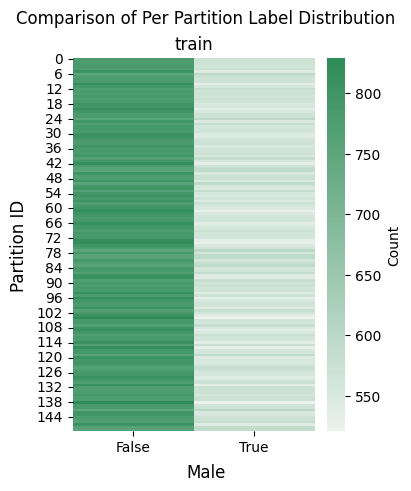

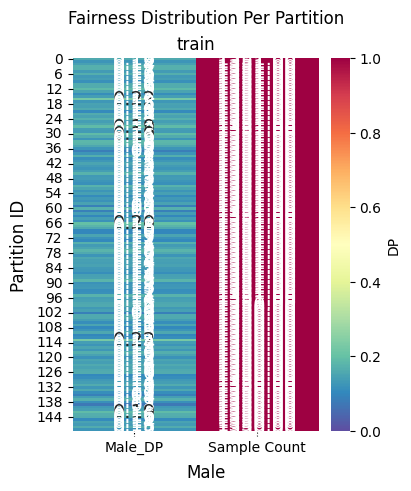

In [3]:
fds = FairFederatedDataset(
    dataset="flwrlabs/celeba",
    split="all",
    partitioners={"train": num_total_clients},
    label_name="Smiling",
    sensitive_attributes=["Male"],
    fairness_metric="DP",
    modification_dict=mod_dict,
)

print("Preparing dataset... This might take a while.")
fds.prepare()
print("Dataset ready.")

## 3. Loading Partitions

We can now load partitions for specific clients. Client 0 belongs to Group A, while Client 80 belongs to Group B.

In [4]:
# Load Client 0 (Group A)
client_0 = fds.load_partition(0, split="train")
print(f"Client 0 size: {len(client_0)}")

# Load Client 80 (Group B)
client_80 = fds.load_partition(80, split="train")
print(f"Client 80 size: {len(client_80)}")

Client 0 size: 1351
Client 80 size: 1351


Now that we have the client data, we can create a PyTorch `DataLoader` using the `ImageDataset` wrapper. The images are stores in the `image` key of the dataset dictionary.

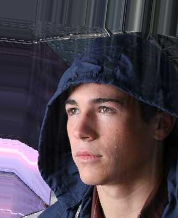

In [ ]:
import io

from PIL import Image

image_bytes = [image_path["bytes"] for image_path in client_0["image"]]

images = [Image.open(io.BytesIO(img_byte)).convert("RGB") for img_byte in image_bytes]
labels = client_0["Smiling"]
sensitive_attributes = client_0["Male"]

# Display first image in the notebook
images[0]  # Display first image in the notebook

In [6]:
labels[0]

False

In [7]:
sensitive_attributes[0]

True

Now, we create a train and a test dataset for client 0 to train and evaluate a simple CNN model.

In [8]:
from sklearn.model_selection import train_test_split

(
    train_0_images,
    test_0_images,
    train_0_labels,
    test_0_labels,
    train_0_sensitive_attributes,
    test_0_sensitive_attributes,
) = train_test_split(images, labels, sensitive_attributes, test_size=0.2, random_state=42)

Define the Celeba Dataset

In [9]:
from torchvision import transforms

transform = transforms.Compose(
    [
        transforms.Resize((64, 64)),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
    ],
)

In [10]:
from FeDa4Fair.utils.example_utils import CelebaDataset

celeba_dataset_train = CelebaDataset(
    images=train_0_images,
    labels=train_0_labels,
    sensitive_attributes=train_0_sensitive_attributes,
    transform=transform,
)

celeba_dataset_test = CelebaDataset(
    images=test_0_images,
    labels=test_0_labels,
    sensitive_attributes=test_0_sensitive_attributes,
    transform=transform,
)

## 4. Train a local model on a client partition

We now use the `train_loader_0` to train a simple CNN model on client 0's data. This is a demonstration of how to use the FeDa4Fair library with image datasets in a federated learning setting.

In [11]:
train_loader_0 = DataLoader(celeba_dataset_train, batch_size=32, shuffle=True)

# Initialize a simple CNN
model = SimpleCNN(num_classes=2)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

print("Training for 4 epochs on Client 0 data...")
for _ in range(4):
    train_celeba(model, train_loader_0, optimizer, device="cpu")
print("Training finished.")

Training for 4 epochs on Client 0 data...
Training finished.


Then, we evaluate the trained model on client 0's data.

In [12]:
test_loader_0 = DataLoader(celeba_dataset_test, batch_size=32, shuffle=False)

loss, accuracy, fairness = test_image(model, test_loader_0, device="cpu", sensitive_attribute_name="male")

print(f"Model Accuracy: {accuracy:.4f}")
print(f"Model Fairness (DP Difference): {fairness['male_DP']['male_DP']:.4f}")

Model Accuracy: 0.8266
Model Fairness (DP Difference): 0.1881


# 5. Training a Federated Learning model

We now train a Federated Learning model on the generated dataset. We use the Flower framework to train the model.
This part of the example is based on the Flower tutorial https://github.com/adap/flower/blob/main/examples/flower-in-30-minutes/tutorial.ipynb

Before starting the training, we have to prepare the dataset partitions for each client and save them to disk.

In [ ]:
# Dataset preparation

for client_id in range(150):
    client_data = fds.load_partition(client_id, split="train")
    image_bytes = [image_path["bytes"] for image_path in client_data["image"]]

    images = [Image.open(io.BytesIO(img_byte)).convert("RGB") for img_byte in image_bytes]
    labels = client_data["Smiling"]
    sensitive_attributes = client_data["Male"]

    (
        train_data_images,
        test_data_images,
        train_data_labels,
        test_data_labels,
        train_data_sensitive_attributes,
        test_data_sensitive_attributes,
    ) = train_test_split(images, labels, sensitive_attributes, test_size=0.2, random_state=42)

    celeba_dataset_train = CelebaDataset(
        images=train_data_images,
        labels=train_data_labels,
        sensitive_attributes=train_data_sensitive_attributes,
        transform=transform,
    )

    celeba_dataset_test = CelebaDataset(
        images=test_data_images,
        labels=test_data_labels,
        sensitive_attributes=test_data_sensitive_attributes,
        transform=transform,
    )

    # Crate the directory if it does not exist
    Path(f"./data/federated/{client_id}").mkdir(parents=True, exist_ok=True)

    torch.save(celeba_dataset_train, Path(f"./data/federated/{client_id}/train.pt"))
    torch.save(celeba_dataset_test, Path(f"./data/federated/{client_id}/test.pt"))

In [ ]:
from pathlib import Path

import torch
from flwr.client import ClientApp, NumPyClient
from flwr.common import Context, NDArrays, Scalar, ndarrays_to_parameters
from flwr.server import ServerApp, ServerAppComponents, ServerConfig
from flwr.server.strategy import FedAvg
from flwr.simulation import run_simulation
from torch.utils.data import DataLoader

from FeDa4Fair.utils.example_utils import get_params, set_params, test_celeba, train_celeba, weighted_average


class FlowerClient(NumPyClient):
    def __init__(self, trainloader, valloader) -> None:
        super().__init__()

        self.trainloader = trainloader
        self.valloader = valloader
        self.model = SimpleCNN(num_classes=2)
        self.device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

    def fit(self, parameters, config):
        """
        This method trains the model using the parameters sent by the
        server on the dataset of this client. At then end, the parameters
        of the locally trained model are communicated back to the server
        """
        # copy parameters sent by the server into client's local model
        set_params(self.model, parameters)

        # Define the optimizer
        optim = torch.optim.SGD(self.model.parameters(), lr=0.01)

        # do local training (call same function as centralised setting)
        train_celeba(self.model, self.trainloader, optim, self.device)

        # return the model parameters to the server as well as extra info (number of training examples in this case)
        return get_params(self.model), len(self.trainloader), {}

    def evaluate(self, parameters: NDArrays, config: dict[str, Scalar]):
        """
        Evaluate the model sent by the server on this client's
        local validation set. Then return performance metrics.
        """
        set_params(self.model, parameters)
        # do local evaluation (call same function as centralised setting)
        loss, accuracy, fairness_dict = test_celeba(self.model, self.valloader, self.device)
        for key, value in fairness_dict.items():
            print(f"Unfairness for {key}: {value[0]}")
        # send the loss and accuracy back to the server
        # send statistics back to the server
        return float(loss), len(self.valloader), {"accuracy": accuracy}

In [15]:
def client_fn(context: Context):
    """Returns a FlowerClient containing its data partition."""
    partition_id = int(context.node_config["partition-id"])

    train = torch.load(Path(f"./data/federated/{partition_id}/train.pt"))
    test = torch.load(Path(f"./data/federated/{partition_id}/test.pt"))
    trainloader = DataLoader(train, batch_size=128, num_workers=5, pin_memory=True, drop_last=False)
    testloader = DataLoader(test, batch_size=128, num_workers=5, pin_memory=True, drop_last=False)

    return FlowerClient(trainloader=trainloader, valloader=testloader).to_client()


# Concstruct the ClientApp passing the client generation function
client_app = ClientApp(client_fn=client_fn)

In [ ]:
num_rounds = 5


def server_fn(_context: Context):
    # instantiate the model
    model = SimpleCNN(num_classes=2)
    ndarrays = get_params(model)
    # Convert model parameters to flwr.common.Parameters
    global_model_init = ndarrays_to_parameters(ndarrays)

    # Define the strategy
    strategy = FedAvg(
        fraction_fit=0.05,  # 5% of clients participate in training
        fraction_evaluate=0.05,  # 5% of clients participate in evaluation
        evaluate_metrics_aggregation_fn=weighted_average,  # callback defined earlier
        initial_parameters=global_model_init,  # initialised global model
    )

    # Construct ServerConfig
    config = ServerConfig(num_rounds=num_rounds)

    # Wrap everything into a `ServerAppComponents` object
    return ServerAppComponents(strategy=strategy, config=config)


# Create your ServerApp
server_app = ServerApp(server_fn=server_fn)

In [17]:
run_simulation(server_app=server_app, client_app=client_app, num_supernodes=150)

INFO :      Starting Flower ServerApp, config: num_rounds=5, no round_timeout
INFO :      
INFO :      [INIT]
INFO :      Using initial global parameters provided by strategy
INFO :      Starting evaluation of initial global parameters
INFO :      Evaluation returned no results (`None`)
INFO :      
INFO :      [ROUND 1]
INFO :      configure_fit: strategy sampled 7 clients (out of 150)
(ClientAppActor pid=45354) /var/folders/_7/49cybzz15pl0x0gncjgqlk5c0000gn/T/ipykernel_43482/3182406744.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Ar

(ClientAppActor pid=45355) Unfairness for SEX_DP: 0.0011506849315068499
(ClientAppActor pid=45355) Unfairness for SEX_EO: 0.006307904592943031


(ClientAppActor pid=45355) /var/folders/_7/49cybzz15pl0x0gncjgqlk5c0000gn/T/ipykernel_43482/4171433464.py:50: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
(ClientAppActor pid=45357) /var/folders/_7/49cybzz15pl0x0gncjgqlk5c0000gn/T/ipykernel_43482/3182406744.py:6: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be 

(ClientAppActor pid=45353) Unfairness for SEX_DP: 0.024390243902439025 [repeated 5x across cluster]
(ClientAppActor pid=45353) Unfairness for SEX_EO: 0.0392156862745098 [repeated 5x across cluster]


(ClientAppActor pid=45355) /var/folders/_7/49cybzz15pl0x0gncjgqlk5c0000gn/T/ipykernel_43482/4171433464.py:50: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
(ClientAppActor pid=45353) /var/folders/_7/49cybzz15pl0x0gncjgqlk5c0000gn/T/ipykernel_43482/3182406744.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be 

...

(ClientAppActor pid=45356) /var/folders/_7/49cybzz15pl0x0gncjgqlk5c0000gn/T/ipykernel_43482/4171433464.py:50: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
(ClientAppActor pid=45357) python(63616) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
(ClientAppActor pid=45354) /var/folders/_7/49cybzz15pl0x0gncjgqlk5c0000gn/T/ipykernel_43482/3182406744.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `

(ClientAppActor pid=45354) Unfairness for SEX_DP: 0.11839788732394368 [repeated 5x across cluster]
(ClientAppActor pid=45354) Unfairness for SEX_EO: 0.07060204595002514 [repeated 5x across cluster]


INFO :      	{'accuracy': [(1, 0.5242644331205217),
INFO :      	              (2, 0.5515707061832523),
INFO :      	              (3, 0.5594369277026103),
INFO :      	              (4, 0.607091118530233),
INFO :      	              (5, 0.590894004178137)]}
INFO :      


(ClientAppActor pid=45356) Unfairness for SEX_DP: 0.037505597850425454
(ClientAppActor pid=45356) Unfairness for SEX_EO: 0.04120787454120786


(ClientAppActor pid=45356) /var/folders/_7/49cybzz15pl0x0gncjgqlk5c0000gn/T/ipykernel_43482/4171433464.py:50: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
python(65212) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
